In [27]:
import uproot
import matplotlib.pyplot as plt
import numpy as np
import mplhep as mplhep
from pathlib import Path
from scipy.ndimage import gaussian_filter,gaussian_filter1d
import os,sys
sys.path.append('/sdf/data/lcls/ds/ued_testfac/scratch/python_packages')
from ued_LCLSII_DAQ_utilities import *

In [2]:
# --- constants (check ePix10k datasheet values for your gain mode) ---
W_SI      = 3.62        # eV per e-h pair
FANO      = 0.128       # Si Fano factor
DIFF_SIGMA_PIX = 0.45   # charge-sharing sigma in *pixel* units (~7 um / 100 um)
READ_NOISE_E   = 420.0   # RMS read noise in 3.12 MeV electrons (mode-dependent)
GAIN_e_per_ADU = 25.0    # set to your calibration
PEDESTAL_ADU   = 0.0
COMMON_MODE_E  = 10.0   # per-row/col offset RMS (optional)

def digitize(edep_MeV):
    # 1. energy -> mean number of electrons
    N = edep_MeV * 1e6 / W_SI

    # 2. Fano fluctuation (only where signal exists)
    sigma_fano = np.sqrt(np.maximum(FANO * N, 0.0))
    N = np.random.normal(N, sigma_fano)
    N = np.clip(N, 0, None)

    # 3. charge sharing: diffuse the charge to neighbors
    N = gaussian_filter(N, sigma=DIFF_SIGMA_PIX, mode='constant')

    # 4. common-mode (per-row offset), optional
    N += np.random.normal(0, COMMON_MODE_E, size=(N.shape[0], 1))

    # 5. electronic read noise (every pixel, even empty ones)
    N += np.random.normal(0, READ_NOISE_E*1000, size=N.shape)

    # 6. gain + pedestal + quantization -> ADU
    adu = N / GAIN_e_per_ADU + PEDESTAL_ADU
    return np.round(adu).astype(int) / (1e4)

In [28]:
sparse_sim_data=np.zeros((20,500))
sparse_sim_bins=np.linspace(0,1,501) * 1000
num_jobs = 20
num_elecs_arr = np.arange(1000,21000,1000)
edep_maps = [[] for i in range(20)]

for i, num_elecs in enumerate(num_elecs_arr):
    for run_num in range(1,num_jobs + 1):
        sim_filename = f"/sdf/home/d/dhruvshr/SULI2026/ePix_Simulation/Examples/PixelSim_ePix_Data_Gen/outputs/sim_{num_elecs}_e-_run_{run_num:03d}.root"
        sim_file = uproot.open(sim_filename)
        sparse_sim_data[i] += sim_file["TotalEdep"].to_numpy()[0]
        edep_maps[i].append(sim_file["EdepMap"].to_numpy()[0])

In [29]:
digi_edep_maps = [[] for i in range(20)]

for i in range(20):
    digi_edep_maps[i] = [digitize(edep_map) for edep_map in edep_maps[i]]

In [39]:
# Define some trial peak finding parameters
max_electrons = 1000  # Max number of electrons the peakFinder allowed to find
threshold     = 40    # Threshold for peak finding, pixel intensity below this is filtered
min_signal    = 100   # Min intensity to be considered as electron signal

num_droplets = np.zeros(20)
xs = [[] for i in range(20)]
ys = [[] for i in range(20)]
droplet_edeps = [[] for i in range(20)]
droplet_sizes = [[] for i in range(20)]

for i,n_elecs in enumerate(range(20)):
    for job_num in range(20):
        digi_edep_map = digi_edep_maps[n_elecs][job_num]
        n, x, y, edep, size = blobCounter(digi_edep_map, threshold, min_signal)
        num_droplets[i] += n
        xs[i].append(x)
        ys[i].append(y)
        droplet_edeps[i] += list(edep)
        droplet_sizes[i] += list(size)

In [41]:
avg_droplet_sizes = np.array([np.mean(np.array(droplet_sizes[i])) for i in range(20)])

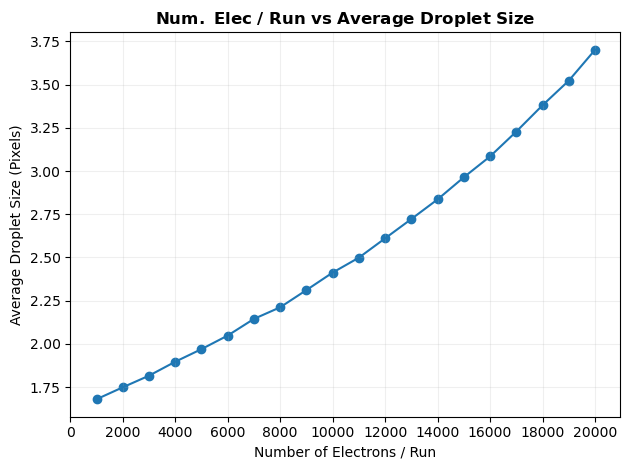

In [68]:
plt.scatter(num_elecs_arr,avg_droplet_sizes)
plt.plot(num_elecs_arr,avg_droplet_sizes)
plt.xlabel("Number of Electrons / Run")
plt.ylabel("Average Droplet Size (Pixels)")
plt.title(r"$\bf{Num.\ Elec\ /\ Run\ vs\ Average\ Droplet\ Size}$")
plt.xticks(np.arange(0,22000,2000))
plt.grid(alpha=0.2)
plt.tight_layout();

In [72]:
avg_droplet_edeps = np.array([np.mean(np.array(droplet_edeps[i])) for i in range(20)])

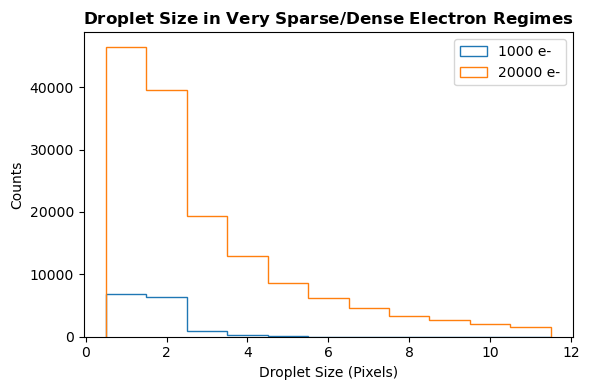

In [87]:
fig,ax = plt.subplots(1,1,figsize=(6,4))
plt.hist(droplet_sizes[0],bins=np.arange(min(droplet_sizes[0]), max(droplet_sizes[0])+2) - 0.5,histtype='step',label='1000 e-')
plt.hist(droplet_sizes[19],bins=np.arange(min(droplet_sizes[0]), max(droplet_sizes[0])+2) - 0.5,histtype='step',label='20000 e-')
plt.title(r"$\bf{Droplet\ Size\ in\ Very\ Sparse/Dense\ Electron\ Regimes}$")
plt.xlabel("Droplet Size (Pixels)")
plt.ylabel("Counts")
plt.legend()
plt.tight_layout();

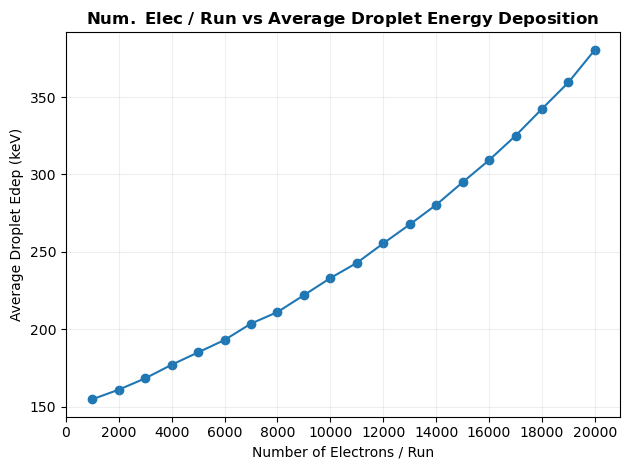

In [88]:
plt.scatter(num_elecs_arr,avg_droplet_edeps)
plt.plot(num_elecs_arr,avg_droplet_edeps)
plt.xlabel("Number of Electrons / Run")
plt.ylabel("Average Droplet Edep (keV)")
plt.title(r"$\bf{Num.\ Elec\ /\ Run\ vs\ Average\ Droplet\ Energy\ Deposition}$")
plt.xticks(np.arange(0,22000,2000))
plt.grid(alpha=0.2)
plt.tight_layout();

In [113]:
for i in np.arange(0,20,4):
    print(i)

0
4
8
12
16


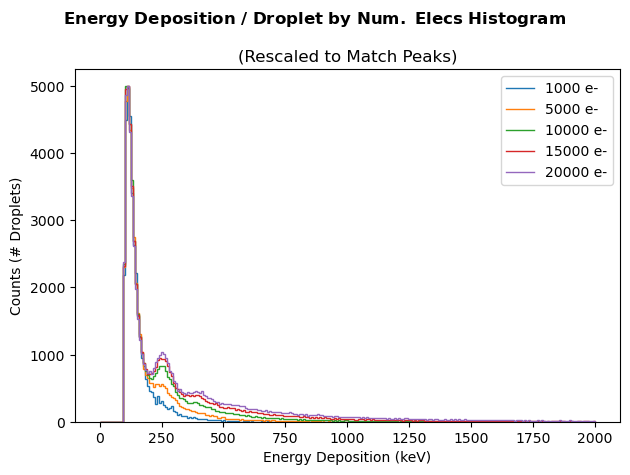

In [127]:
match_peak = 5000 # peak counts to match
bins = np.linspace(0,2000,250)

for i in [0,4,9,14,19]:
    counts,_ = np.histogram(droplet_edeps[i],bins=bins)
    ratio = match_peak / max(counts)
    plt.stairs(counts * ratio, bins, label=f'{1000 * (i+1)} e-')

plt.xlabel("Energy Deposition (keV)")
plt.ylabel("Counts (# Droplets)")
plt.suptitle(r"$\bf{Energy\ Deposition\ /\ Droplet\ by\ Num.\ Elecs\ Histogram}$")
plt.title("(Rescaled to Match Peaks)")
plt.legend()
plt.tight_layout()

In [128]:
def get_hist_mean(hist):
    counts, edges = hist[0], hist[1]
    bin_centers = (edges[:-1] + edges[1:]) / 2
    mean = np.average(bin_centers, weights=counts)
    return mean

def get_exp_data(run, is_sparse):
    if (is_sparse):
        exp_py = np.load('../../../ePix_Analysis/catalog/Intensity_evts_run_'+str(run)+'_sparse.npy')
    else:
        exp_py = np.load('../../../ePix_Analysis/catalog/Intensity_evts_run_'+str(run)+'_dense.npy')
    bins_intn=np.arange(80,1000,5)
    all_counts = []
    for i_mdl in range(4):
        hist_intn, bin_edges = np.histogram(exp_py[:,i_mdl,:].flatten(), bins=bins_intn)
        all_counts.append(hist_intn)
    exp_counts = np.mean(np.array(all_counts), axis=0)
    return exp_counts

### Comparing with Experiment: Sparse & Dense Cases

In [171]:
exp_126 = get_exp_data(126,True)
exp_126_dense = get_exp_data(126,False)
exp_bins = np.linspace(80,995,184)[:-1]

In [181]:
detector_noise = 5
sigma_bins = detector_noise / 2

Compare the sparse experimental data with the sparsest simulated run we have (1000 e-)

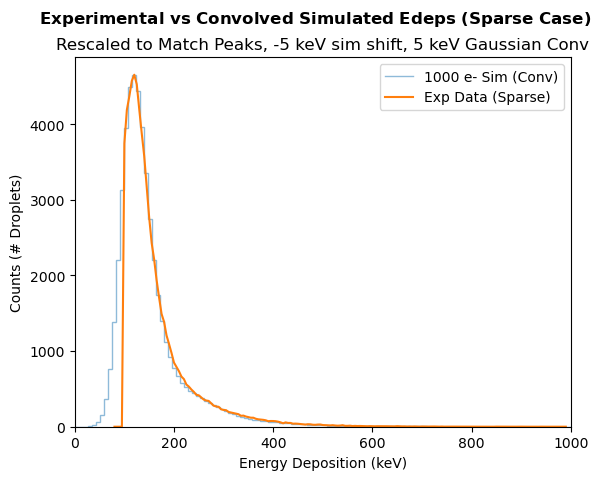

In [193]:
bins = np.linspace(0,2000,250)
bin_shift = -5
counts,_ = np.histogram(droplet_edeps[0],bins=bins)
conv_sparse_data = gaussian_filter1d(counts.astype(float), sigma_bins, mode='constant', cval=0)
match_peak = max(conv_sparse_data)
ratio = max(exp_126) / match_peak
plt.stairs(conv_sparse_data * ratio, bins + bin_shift, label=f'{1000 * (i+1)} e- Sim (Conv)',alpha=0.5)

plt.plot(exp_bins,exp_126, label='Exp Data (Sparse)')

plt.xlabel("Energy Deposition (keV)")
plt.ylabel("Counts (# Droplets)")
plt.suptitle(r"$\bf{Experimental\ vs\ Convolved\ Simulated\ Edeps\ (Sparse\ Case)}$")
plt.title(f"Rescaled to Match Peaks, {bin_shift} keV sim shift, {detector_noise} keV Gaussian Conv")
plt.legend()
plt.xlim(0,1000);

Now compare the dense experimental case with a denser simulated run. You can change which run is used with `sim_num`, but the simulation with index 3 (4000 e-) fits best in this case.

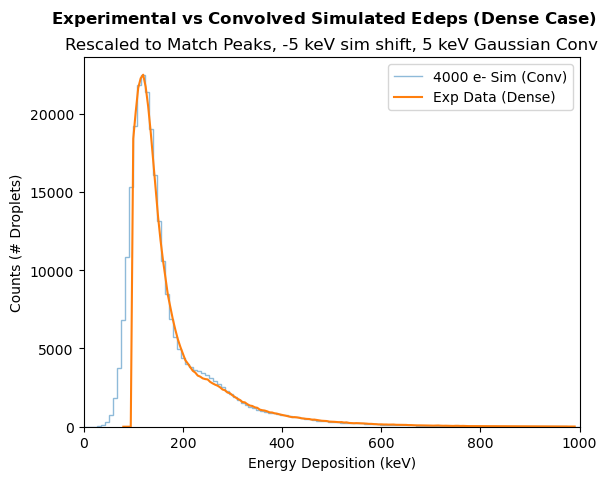

In [194]:
bins = np.linspace(0,2000,250)

sim_num = 3
counts,_ = np.histogram(droplet_edeps[sim_num],bins=bins)
conv_sparse_data = gaussian_filter1d(counts.astype(float), sigma_bins, mode='constant', cval=0)
match_peak = max(conv_sparse_data)
ratio = max(exp_126_dense) / match_peak
plt.stairs(conv_sparse_data * ratio, bins - 5, label=f'{1000 * (sim_num + 1)} e- Sim (Conv)',alpha=0.5)

plt.plot(exp_bins,exp_126_dense, label='Exp Data (Dense)')

plt.xlabel("Energy Deposition (keV)")
plt.ylabel("Counts (# Droplets)")
plt.suptitle(r"$\bf{Experimental\ vs\ Convolved\ Simulated\ Edeps\ (Dense\ Case)}$")
plt.title(f"Rescaled to Match Peaks, {bin_shift} keV sim shift, {detector_noise} keV Gaussian Conv")
plt.legend()
plt.xlim(0,1000);